# Random Forest — Ensemble Learning

## What is a Random Forest?

A **Random Forest** is a powerful ensemble machine learning algorithm that builds a *forest* of decision trees and aggregates their predictions. It is one of the most widely used algorithms in practice because it:

- Handles **high-dimensional** data well
- Is **robust to overfitting** (thanks to bagging + feature randomness)
- Works for both **classification** and **regression** tasks
- Provides **feature importance** scores out of the box
- Requires **minimal hyperparameter tuning**

---

## How Does It Work?

Random Forest combines two key ideas:

| Concept | Description |
|---|---|
| **Bootstrap Aggregating (Bagging)** | Each tree is trained on a random subset (with replacement) of the training data |
| **Feature Randomness** | At each split, only a random subset of features is considered |

The final prediction is made by **majority vote** (classification) or **averaging** (regression) across all trees.

---

In [59]:
# Import required libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import seaborn as sns
import numpy as np

# Set style for clean plots
plt.style.use('default')

### Load & Explore the Dataset

### Breast Cancer Wisconsin Dataset

This is a classic binary classification dataset built into scikit-learn.

| Property | Value |
|---|---|
| **Samples** | 569 |
| **Features** | 30 (numeric) |
| **Classes** | 2 — `malignant` (0) and `benign` (1) |
| **Task** | Binary Classification |

Each feature describes characteristics of the cell nuclei present in the tumour (e.g. radius, texture, perimeter, area, smoothness, etc.) computed from digitized images of fine needle aspirate (FNA) biopsies.

In [40]:
# Load Breast Cancer dataset
cancer = load_breast_cancer()

# Features and target
X = cancer.data
y = cancer.target

# Feature names
feature_names = cancer.feature_names

# Quick look at data
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Class names:", cancer.target_names)

Features shape: (569, 30)
Target shape: (569,)
Class names: ['malignant' 'benign']


### Train / Test Split

We split the data into a **training set (80%)** and a **test set (20%)**.

- The model **learns** from the training set.
- The model is **evaluated** on the unseen test set to estimate real-world performance.

We use `random_state=42` for **reproducibility**, and `stratify=y` so that both splits preserve the original class ratio.

In [43]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 455
Test samples: 114


### Train the Random Forest Model

Create a `RandomForestClassifier` with **100 trees** (`n_estimators=100`). Key hyperparameters to know:

| Parameter | Meaning | Our Value |
|---|---|---|
| `n_estimators` | Number of decision trees in the forest | 100 |
| `max_features` | Features to consider at each split | `'sqrt'` (default) |
| `max_depth` | Maximum depth of each tree | `None` (unlimited) |
| `random_state` | Seed for reproducibility | 42 |

In [46]:
# Create and train the model
model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    random_state=42        # for reproducibility
)

# Fit the model
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


### Evaluate the Model

### Metrics Used

| Metric | Description |
|---|---|
| **Accuracy** | % of correct predictions |
| **Precision** | Of all predicted positives, how many were actually positive? |
| **Recall** | Of all actual positives, how many did the model find? |
| **F1-Score** | Harmonic mean of Precision and Recall |

In [49]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# Accuracies
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", round(train_acc, 3))
print("Test Accuracy: ", round(test_acc, 3))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=cancer.target_names))

Train Accuracy: 1.0
Test Accuracy:  0.965

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### Confusion Matrix

A **confusion matrix** breaks down predictions into four categories:

| | Predicted Malignant | Predicted Benign |
|---|---|---|
| **Actual Malignant** | True Positive (TP) | False Negative (FN) |
| **Actual Benign** | False Positive (FP) | True Negative (TN) |

- **False Negatives** (missing a cancer) → most dangerous in medical settings
- **False Positives** (flagging healthy as cancerous) → leads to unnecessary procedures

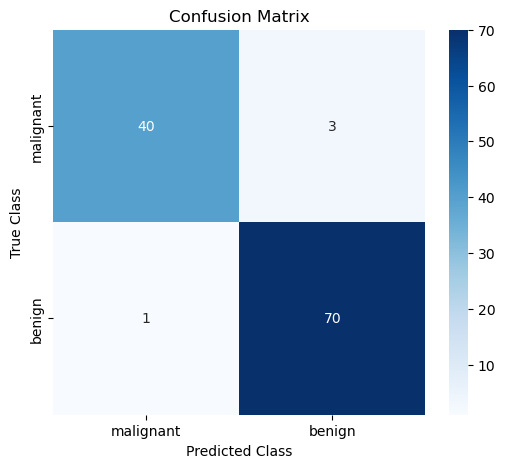

In [52]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

### Feature Importance

Random Forest computes a **feature importance score** for each feature, measured as the average reduction in impurity (Gini or entropy) that the feature brings across all trees.

Higher importance → the feature is more useful for making correct predictions.

>  Feature importance helps with **interpretability** and can guide **feature selection** — dropping low-importance features can speed up training without hurting performance.

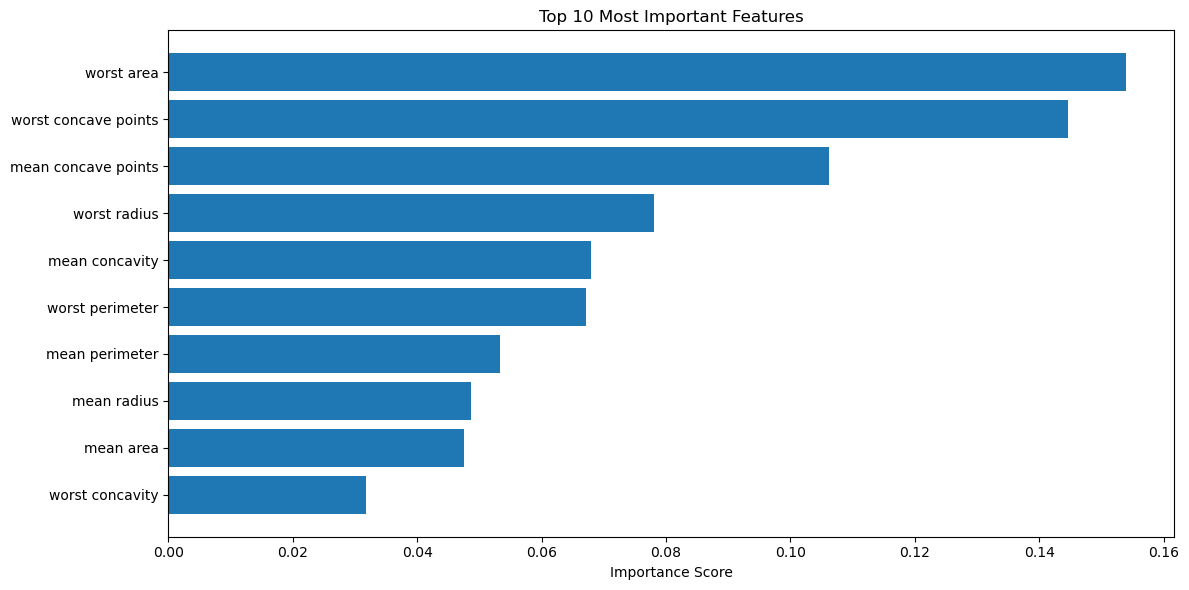

In [63]:
# Feature importances
importances = model.feature_importances_

# Top 10 features
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(12, 6))
plt.barh(feature_names[indices], importances[indices])
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()